# Homework 1 - Fashion-MNIST: Baseline MLP & Regularization

## Yiğit Sert - Y255050003

This notebook trains three variants of a Multi-Layer Perceptron on the Fashion-MNIST dataset:

| Variant | Configuration |
|---------|---------------|
| **Baseline** | No regularization |
| **+ Dropout** | `Dropout(0.3)` after the hidden layer |
| **+ L2 + EarlyStopping** | `kernel_regularizer=l2(1e-4)` + `EarlyStopping(patience=3)` |

For each variant we plot **training vs. validation loss** across epochs and report **final test accuracy**.

## 1. Imports & Reproducibility

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Best-effort reproducibility
tf.keras.utils.set_random_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Data Loading, Normalization & Splitting

Fashion-MNIST contains 70 000 grayscale 28×28 images across 10 clothing categories.

- Pixel values are normalized to **[0, 1]** for numerical stability.
- The last 10 000 training samples are held out as a **validation set**.
- The original test split (10 000 samples) is **never touched until final evaluation**.

In [12]:
# Load raw data
(x_train_full, y_train_full), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)

# Normalize pixels to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32")       / 255.0

# Train / validation split (last 10 000 samples become validation)
x_val,   y_val   = x_train_full[-10000:], y_train_full[-10000:]
x_train, y_train = x_train_full[:-10000], y_train_full[:-10000]

print(f"Training samples   : {len(x_train):,}")
print(f"Validation samples : {len(x_val):,}")
print(f"Test samples       : {len(x_test):,}")
print(f"Image shape        : {x_train.shape[1:]}")

Training samples   : 50,000
Validation samples : 10,000
Test samples       : 10,000
Image shape        : (28, 28)


## 3. Model Factory

A single helper function builds each variant to keep the architecture consistent.
The only difference between variants is whether **Dropout** or **L2 regularization** is injected.

In [13]:
def build_model(dropout_rate=0.0, l2_lambda=0.0):
    """Build a Flatten → Dense(256, relu) → [optional Dropout] → Dense(10) MLP.

    Args:
        dropout_rate: Fraction of units to drop after the hidden layer (0 = disabled).
        l2_lambda   : L2 regularization strength on the hidden layer weights (0 = disabled).

    Returns:
        Compiled (but untrained) tf.keras.Sequential model.
    """
    regularizer = tf.keras.regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    layers = [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=regularizer),
    ]

    if dropout_rate > 0:
        layers.append(tf.keras.layers.Dropout(dropout_rate))

    layers.append(tf.keras.layers.Dense(10))  # logits — no softmax here

    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return model

## 4. Training

All three variants share the same hyperparameters:
- **Epochs**: up to 20
- **Batch size**: 128
- **Optimizer**: Adam with lr = 10⁻³
- **Loss**: `SparseCategoricalCrossentropy(from_logits=True)`


The L2 variant explicitly requires `EarlyStopping(patience=3)` per the assignment spec.

In [14]:
EPOCHS     = 20
BATCH_SIZE = 128

# Shared fit kwargs
fit_kwargs = dict(
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

def make_callbacks(patience_es=3, patience_lr=2):
    """Return a standard callback list: EarlyStopping + ReduceLROnPlateau."""
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=patience_lr,
            factor=0.5,
            verbose=1,
        ),
    ]

### 4.1 Variant 1 — Baseline (no regularization)

In [15]:
print("=" * 60)
print("VARIANT 1: Baseline")
print("=" * 60)

model_baseline = build_model()
history_baseline = model_baseline.fit(
    x_train, y_train,
    **fit_kwargs
)

VARIANT 1: Baseline
Epoch 1/20
391/391 - 5s - 12ms/step - accuracy: 0.8125 - loss: 0.5396 - val_accuracy: 0.8510 - val_loss: 0.4335
Epoch 2/20
391/391 - 3s - 7ms/step - accuracy: 0.8586 - loss: 0.3980 - val_accuracy: 0.8593 - val_loss: 0.4016
Epoch 3/20
391/391 - 3s - 8ms/step - accuracy: 0.8726 - loss: 0.3548 - val_accuracy: 0.8718 - val_loss: 0.3660
Epoch 4/20
391/391 - 4s - 11ms/step - accuracy: 0.8816 - loss: 0.3273 - val_accuracy: 0.8758 - val_loss: 0.3526
Epoch 5/20
391/391 - 3s - 8ms/step - accuracy: 0.8893 - loss: 0.3066 - val_accuracy: 0.8748 - val_loss: 0.3515
Epoch 6/20
391/391 - 3s - 7ms/step - accuracy: 0.8952 - loss: 0.2897 - val_accuracy: 0.8782 - val_loss: 0.3451
Epoch 7/20
391/391 - 3s - 7ms/step - accuracy: 0.8999 - loss: 0.2759 - val_accuracy: 0.8763 - val_loss: 0.3470
Epoch 8/20
391/391 - 6s - 14ms/step - accuracy: 0.9049 - loss: 0.2623 - val_accuracy: 0.8802 - val_loss: 0.3420
Epoch 9/20
391/391 - 5s - 12ms/step - accuracy: 0.9091 - loss: 0.2513 - val_accuracy: 0.8

### 4.2 Variant 2 — Dropout (rate = 0.3)

In [16]:
print("=" * 60)
print("VARIANT 2: Dropout(0.3)")
print("=" * 60)

model_dropout = build_model(dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train, y_train,
    **fit_kwargs
)

VARIANT 2: Dropout(0.3)
Epoch 1/20
391/391 - 6s - 14ms/step - accuracy: 0.7932 - loss: 0.5915 - val_accuracy: 0.8443 - val_loss: 0.4498
Epoch 2/20
391/391 - 3s - 8ms/step - accuracy: 0.8489 - loss: 0.4238 - val_accuracy: 0.8555 - val_loss: 0.4019
Epoch 3/20
391/391 - 3s - 8ms/step - accuracy: 0.8619 - loss: 0.3834 - val_accuracy: 0.8672 - val_loss: 0.3740
Epoch 4/20
391/391 - 4s - 11ms/step - accuracy: 0.8701 - loss: 0.3591 - val_accuracy: 0.8707 - val_loss: 0.3602
Epoch 5/20
391/391 - 4s - 9ms/step - accuracy: 0.8757 - loss: 0.3397 - val_accuracy: 0.8719 - val_loss: 0.3480
Epoch 6/20
391/391 - 3s - 8ms/step - accuracy: 0.8825 - loss: 0.3259 - val_accuracy: 0.8753 - val_loss: 0.3432
Epoch 7/20
391/391 - 6s - 15ms/step - accuracy: 0.8852 - loss: 0.3136 - val_accuracy: 0.8781 - val_loss: 0.3376
Epoch 8/20
391/391 - 4s - 10ms/step - accuracy: 0.8874 - loss: 0.3073 - val_accuracy: 0.8802 - val_loss: 0.3342
Epoch 9/20
391/391 - 3s - 8ms/step - accuracy: 0.8907 - loss: 0.2950 - val_accuracy:

### 4.3 Variant 3 — L2 Regularization + EarlyStopping

In [17]:
print("=" * 60)
print("VARIANT 3: L2(1e-4) + EarlyStopping(patience=3)")
print("=" * 60)

model_l2 = build_model(l2_lambda=1e-4)

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_l2 = model_l2.fit(
    x_train, y_train,
    callbacks=[es_callback],
    **fit_kwargs
)

VARIANT 3: L2(1e-4) + EarlyStopping(patience=3)
Epoch 1/20
391/391 - 6s - 15ms/step - accuracy: 0.8136 - loss: 0.5799 - val_accuracy: 0.8484 - val_loss: 0.4816
Epoch 2/20
391/391 - 3s - 8ms/step - accuracy: 0.8584 - loss: 0.4391 - val_accuracy: 0.8605 - val_loss: 0.4431
Epoch 3/20
391/391 - 3s - 8ms/step - accuracy: 0.8701 - loss: 0.4016 - val_accuracy: 0.8565 - val_loss: 0.4365
Epoch 4/20
391/391 - 6s - 16ms/step - accuracy: 0.8781 - loss: 0.3771 - val_accuracy: 0.8682 - val_loss: 0.4115
Epoch 5/20
391/391 - 3s - 9ms/step - accuracy: 0.8845 - loss: 0.3595 - val_accuracy: 0.8715 - val_loss: 0.3997
Epoch 6/20
391/391 - 3s - 8ms/step - accuracy: 0.8893 - loss: 0.3462 - val_accuracy: 0.8769 - val_loss: 0.3912
Epoch 7/20
391/391 - 3s - 8ms/step - accuracy: 0.8937 - loss: 0.3348 - val_accuracy: 0.8812 - val_loss: 0.3838
Epoch 8/20
391/391 - 5s - 12ms/step - accuracy: 0.8977 - loss: 0.3245 - val_accuracy: 0.8807 - val_loss: 0.3837
Epoch 9/20
391/391 - 4s - 10ms/step - accuracy: 0.9016 - loss

## 5. Learning Curves

Each subplot shows **training loss** (solid) vs. **validation loss** (dashed) across epochs.  
A growing gap between the two lines is the canonical sign of **overfitting**.

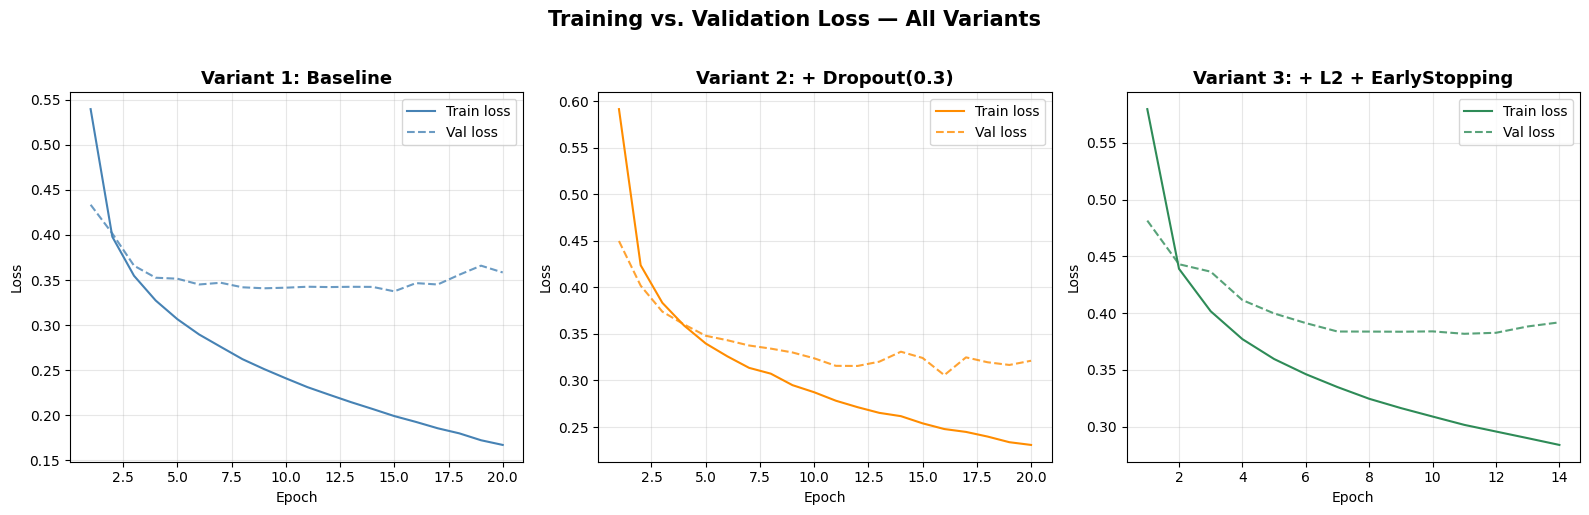

Figure saved to learning_curves.png


In [18]:
def plot_learning_curve(ax, history, title, color="steelblue"):
    """Plot train and validation loss on a given Axes object."""
    epochs = range(1, len(history.history["loss"]) + 1)
    ax.plot(epochs, history.history["loss"],     color=color, linestyle="-",  label="Train loss")
    ax.plot(epochs, history.history["val_loss"], color=color, linestyle="--", label="Val loss",  alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Training vs. Validation Loss — All Variants", fontsize=15, fontweight="bold", y=1.02)

plot_learning_curve(axes[0], history_baseline, "Variant 1: Baseline",          color="steelblue")
plot_learning_curve(axes[1], history_dropout,  "Variant 2: + Dropout(0.3)",    color="darkorange")
plot_learning_curve(axes[2], history_l2,       "Variant 3: + L2 + EarlyStopping", color="seagreen")

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to learning_curves.png")

## 6. Final Test Accuracy

In [19]:
variants = [
    ("Baseline",                 model_baseline),
    ("+Dropout(0.3)",            model_dropout),
    ("+L2(1e-4)+EarlyStopping",  model_l2),
]

results = []
for name, model in variants:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append({"Variant": name, "Test Accuracy": f"{test_acc:.4f}"})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                Variant Test Accuracy
               Baseline        0.8778
          +Dropout(0.3)        0.8863
+L2(1e-4)+EarlyStopping        0.8764


## 7. Discussion

The Baseline model exhibits a noticeable and widening gap between the training and validation loss, which is a clear indicator of overfitting. Adding Dropout (0.3) effectively mitigates this issue by reducing the train-val gap and achieving the highest test accuracy of 0.8863, making it the best generalizing model among the three. While the L2 regularization combined with EarlyStopping successfully halts training to prevent further degradation and keeps the gap tight, it yields a slightly lower final test accuracy of 0.8764 in this specific setup. Therefore, the Dropout variant demonstrates the most effective generalization for this architecture on the Fashion-MNIST dataset.